# Evaluación final — funciones y plan (Fase 7 de la guía)

Este notebook prepara las funciones de evaluación **antes** de tener un modelo
final, para no improvisarlas bajo presión cuando llegue el momento de tocar
test. No depende de las features concretas que entregue `feature/preprocessing`
ni del algoritmo que elija `feature/modeling`: solo necesita un vector
`y_true` y un vector `y_pred`.

**Regla de oro que fija este notebook:** el conjunto de test se evalúa **una
única vez**, con el modelo ya optimizado. Todo lo que aparece aquí con datos de
juguete es una demostración de que las funciones funcionan — no es la
evaluación real.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 1. Métricas (mismo contrato que `feature/modeling`)

Reutiliza la misma definición de MAE/RMSE/R² fijada en `notebooks/modeling.ipynb`
para que el número que sale aquí sea comparable con la tabla de baselines.

In [2]:
def evaluar(y_true, y_pred, nombre=''):
    return {
        'modelo': nombre,
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred),
    }

## 2. Análisis de residuos (Paso 33.2)

Dos vistas estándar para regresión:

- **Real vs. predicho**: los puntos deberían pegarse a la diagonal; una nube
  con forma de abanico indica que el error crece con la magnitud de la demanda.
- **Residuos vs. predicho**: si hay un patrón (curva, embudo) en vez de una
  nube sin estructura, el modelo se está dejando señal por explicar.

In [3]:
def plot_pred_vs_real(y_true, y_pred, titulo=''):
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(y_true, y_pred, alpha=0.5, s=20)
    lims = [min(np.min(y_true), np.min(y_pred)), max(np.max(y_true), np.max(y_pred))]
    ax.plot(lims, lims, 'r--', linewidth=1)
    ax.set_xlabel('Real (n_citas)')
    ax.set_ylabel('Predicho')
    ax.set_title(f'Real vs. predicho {titulo}')
    plt.tight_layout()
    return fig


def plot_residuos(y_true, y_pred, titulo=''):
    residuos = np.asarray(y_true) - np.asarray(y_pred)
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].scatter(y_pred, residuos, alpha=0.5, s=20)
    axes[0].axhline(0, color='r', linestyle='--', linewidth=1)
    axes[0].set_xlabel('Predicho')
    axes[0].set_ylabel('Residuo (real - predicho)')
    axes[0].set_title(f'Residuos vs. predicho {titulo}')
    axes[1].hist(residuos, bins=20)
    axes[1].set_xlabel('Residuo')
    axes[1].set_title('Distribución de residuos')
    plt.tight_layout()
    return fig

## 3. Demo con datos de juguete

Solo para comprobar que las funciones no rompen — **no es la evaluación real**.
Simula un modelo con algo de sesgo en los picos, a propósito, para que se vea
que el análisis de residuos lo detectaría.

{'modelo': 'demo (datos de juguete)', 'MAE': 1.155039379017988, 'RMSE': np.float64(1.432171640195906), 'R2': 0.6451111483525795}


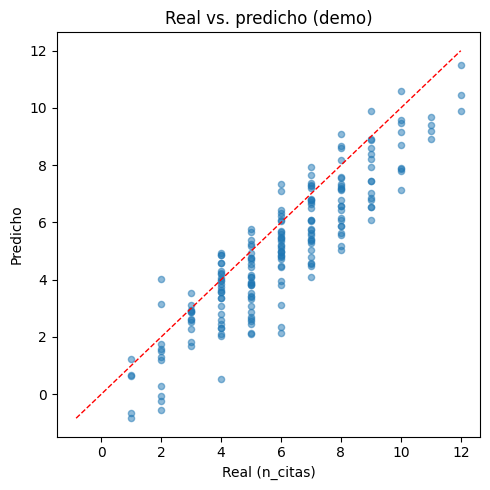

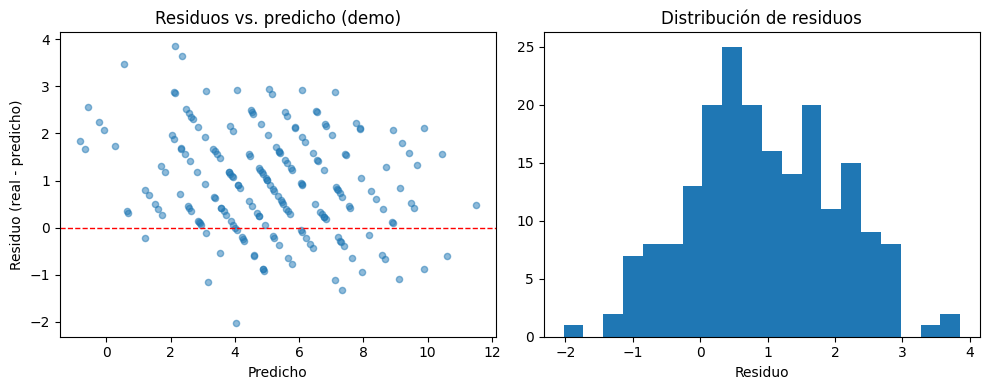

In [4]:
rng = np.random.default_rng(42)
y_true_demo = rng.poisson(lam=6, size=200)
y_pred_demo = y_true_demo * 0.85 + rng.normal(0, 1, size=200)  # sesgo simulado

print(evaluar(y_true_demo, y_pred_demo, 'demo (datos de juguete)'))
_ = plot_pred_vs_real(y_true_demo, y_pred_demo, '(demo)')
_ = plot_residuos(y_true_demo, y_pred_demo, '(demo)')

## 4. Interpretabilidad (Paso 34)

Pendiente del modelo final elegido en `feature/modeling`:

- Si es un modelo de árboles (`RandomForest`/`GradientBoosting`):
  `modelo.feature_importances_`, ordenado y graficado en barras horizontales.
- Si es lineal (`Ridge`/`LinearRegression`): `modelo.coef_` con el nombre de
  cada feature, para poder decir "cada festivo suma X citas de media".

## 5. Contraste con el problema de negocio (Paso 35)

Preguntas a responder cuando exista el modelo final, no antes:

- ¿El MAE en tramos (p. ej. ±2-3 citas) es asumible para decidir cuánto
  personal poner en sala, o el margen de error obliga a sobre-dotar siempre
  "por si acaso"?
- ¿El modelo falla más en fechas concretas (festivos, San Valentín) donde
  equivocarse sale más caro al negocio?
- Limitaciones honestas: la serie cubre poco más de 2 años, así que patrones
  anuales (Navidad, verano) están validados con muy pocas repeticiones.

## 6. Checklist para cuando llegue el modelo final

- [ ] Evaluar el modelo optimizado contra test **una sola vez** con `evaluar()`.
- [ ] `plot_pred_vs_real` y `plot_residuos` sobre las predicciones reales de test.
- [ ] Importancia de features / coeficientes del modelo final.
- [ ] Redactar la sección "Contraste con el problema de negocio" con números
  reales, no con las preguntas de la plantilla.